In [ ]:
# ============================================================
# EXPERIMENT 7 - AUTOENCODERS
# Part 1: Import Libraries and Basic Setup
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers, Model

from sklearn.metrics import mean_squared_error, mean_absolute_error
from skimage.metrics import structural_similarity as ssim

import time
import warnings

warnings.filterwarnings("ignore")

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)

# Check GPU
print("\nGPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
NumPy version: 2.1.3

GPU Available: []


In [ ]:
# ============================================================
# PART 2: LOAD AND PREPROCESS MNIST
# ============================================================

# Load MNIST
(x_train_full, y_train_full), (x_test_full, y_test_full) = keras.datasets.mnist.load_data()

print("Original training data shape:", x_train_full.shape)
print("Original test data shape:", x_test_full.shape)

# ------------------------------------------------------------
# Use the laboratory-recommended subset
# 10,000 training images
# 2,000 test images
# ------------------------------------------------------------

x_train = x_train_full[:10000]
y_train = y_train_full[:10000]

x_test = x_test_full[:2000]
y_test = y_test_full[:2000]

# Normalize pixel values
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Add channel dimension
# (10000, 28, 28) -> (10000, 28, 28, 1)

x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

print("\nAfter preprocessing:")
print("Training images:", x_train.shape)
print("Test images:", x_test.shape)

print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Original training data shape: (60000, 28, 28)
Original test data shape: (10000, 28, 28)

After preprocessing:
Training images: (10000, 28, 28, 1)
Test images: (2000, 28, 28, 1)
Minimum pixel value: 0.0
Maximum pixel value: 1.0


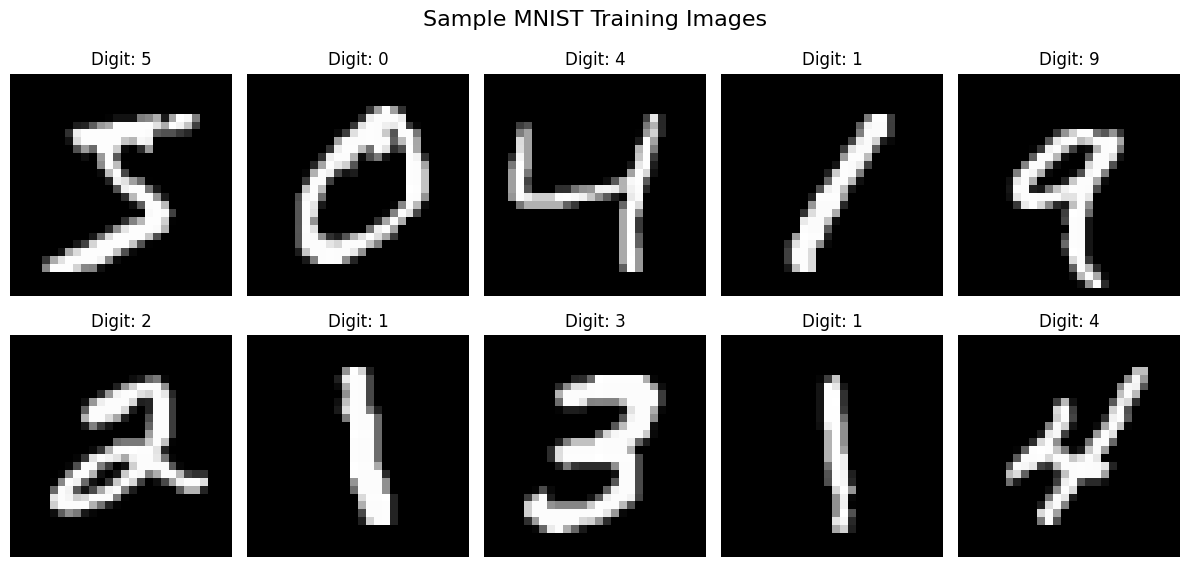

In [ ]:
# ============================================================
# PART 3: VISUALIZE MNIST DATA
# ============================================================

plt.figure(figsize=(12, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].squeeze(), cmap="gray")
    plt.title(f"Digit: {y_train[i]}")
    plt.axis("off")

plt.suptitle("Sample MNIST Training Images", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# PART 4: FULLY CONNECTED AUTOENCODER
# ============================================================

latent_dim = 16

# ------------------------------------------------------------
# Encoder
# ------------------------------------------------------------

fc_encoder = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(latent_dim, activation="relu")
], name="FC_Encoder")


# ------------------------------------------------------------
# Decoder
# ------------------------------------------------------------

fc_decoder = keras.Sequential([
    layers.Input(shape=(latent_dim,)),

    layers.Dense(32, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(784, activation="sigmoid"),

    layers.Reshape((28, 28, 1))
], name="FC_Decoder")


# ------------------------------------------------------------
# Complete Autoencoder
# ------------------------------------------------------------

fc_input = keras.Input(shape=(28, 28, 1))

fc_latent = fc_encoder(fc_input)
fc_output = fc_decoder(fc_latent)

fc_autoencoder = Model(
    fc_input,
    fc_output,
    name="Fully_Connected_Autoencoder"
)

# ------------------------------------------------------------
# Compile
# ------------------------------------------------------------

fc_autoencoder.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy"
)

fc_autoencoder.summary()

Model: "Fully_Connected_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FC_Encoder (Sequential)         │ (None, 16)             │       105,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FC_Decoder (Sequential)         │ (None, 28, 28, 1)      │       105,904 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 211,040 (824.38 KB)

 Trainable params: 211,040 (824.38 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================================
# PART 5: TRAIN FULLY CONNECTED AUTOENCODER
# ============================================================

start_time = time.time()

fc_history = fc_autoencoder.fit(
    x_train,
    x_train,

    validation_data=(x_test, x_test),

    epochs=20,
    batch_size=128,

    shuffle=True,
    verbose=1
)

fc_training_time = time.time() - start_time

print(f"\nFC-AE Training Time: {fc_training_time:.2f} seconds")

Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.3433 - val_loss: 0.2511
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.2354 - val_loss: 0.2108
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.1998 - val_loss: 0.1841
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.1769 - val_loss: 0.1721
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.1677 - val_loss: 0.1652
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.1611 - val_loss: 0.1590
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.1552 - val_loss: 0.1537
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.1506 - val_loss: 0.1499
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1470 - val_loss: 0.1470
Epoch 10/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.1439 - val_loss: 0.1445
Epoch 11/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.1413 - val_loss: 0.1427
Epoch 12/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.13

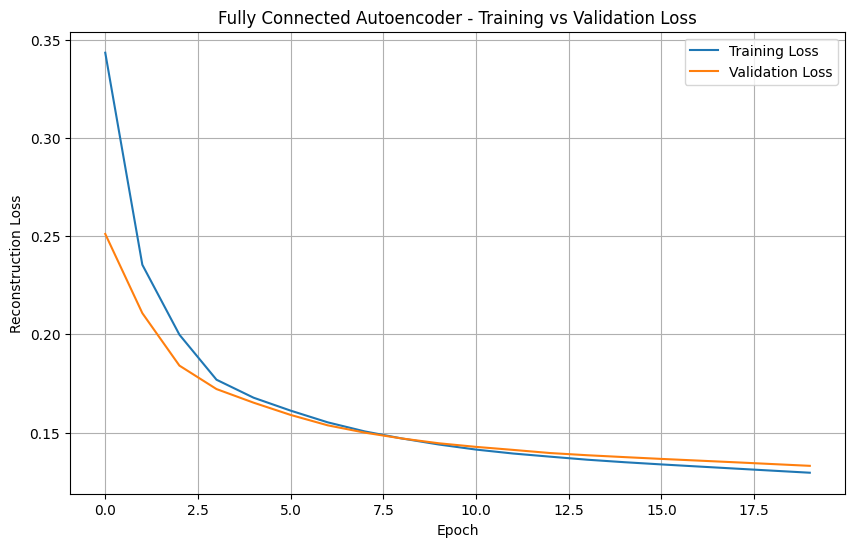

In [ ]:
# ============================================================
# PART 6: FC-AE TRAINING AND VALIDATION LOSS
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    fc_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    fc_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss")
plt.title("Fully Connected Autoencoder - Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

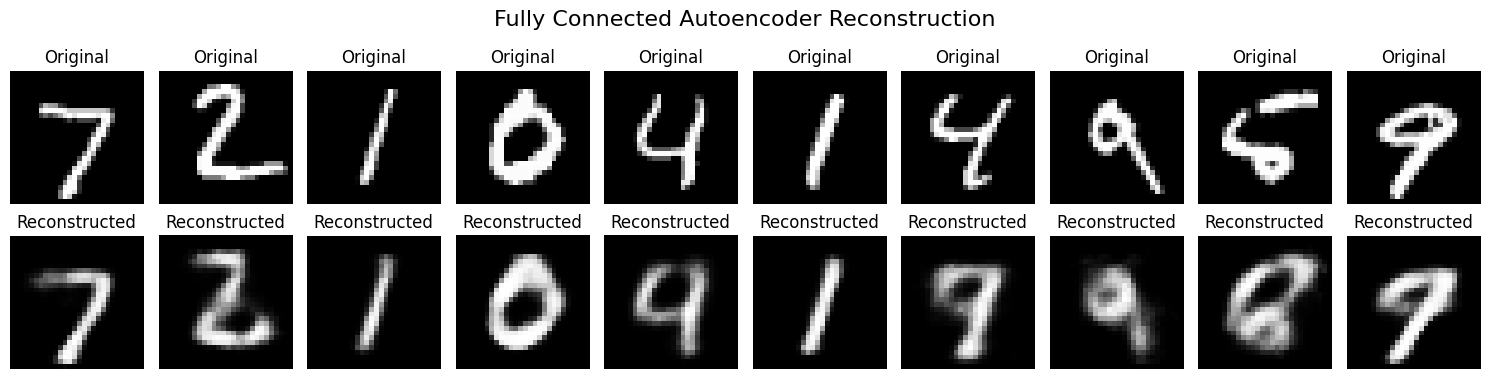

In [ ]:
# ============================================================
# PART 7: ORIGINAL VS RECONSTRUCTED IMAGES
# ============================================================

fc_reconstructed = fc_autoencoder.predict(
    x_test,
    batch_size=128,
    verbose=0
)

n = 10

plt.figure(figsize=(15, 4))

for i in range(n):

    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # Reconstruction
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(fc_reconstructed[i].squeeze(), cmap="gray")
    plt.title("Reconstructed")
    plt.axis("off")

plt.suptitle("Fully Connected Autoencoder Reconstruction", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# PART 8: RECONSTRUCTION METRICS
# MSE, MAE, SSIM
# ============================================================

def calculate_metrics(original, reconstructed):

    # MSE
    mse = np.mean(
        (original - reconstructed) ** 2
    )

    # MAE
    mae = np.mean(
        np.abs(original - reconstructed)
    )

    # SSIM per image
    ssim_values = []

    for i in range(len(original)):

        original_img = original[i].squeeze()
        reconstructed_img = reconstructed[i].squeeze()

        score = ssim(
            original_img,
            reconstructed_img,
            data_range=1.0
        )

        ssim_values.append(score)

    mean_ssim = np.mean(ssim_values)

    return mse, mae, mean_ssim


fc_mse, fc_mae, fc_ssim = calculate_metrics(
    x_test,
    fc_reconstructed
)

print("======================================")
print("FULLY CONNECTED AUTOENCODER RESULTS")
print("======================================")
print(f"MSE  : {fc_mse:.6f}")
print(f"MAE  : {fc_mae:.6f}")
print(f"SSIM : {fc_ssim:.6f}")
print(f"Parameters: {fc_autoencoder.count_params():,}")
print(f"Training Time: {fc_training_time:.2f} seconds")

FULLY CONNECTED AUTOENCODER RESULTS
MSE  : 0.024054
MAE  : 0.062523
SSIM : 0.715698
Parameters: 211,040
Training Time: 22.60 seconds


In [ ]:
# ============================================================
# PART 9: CONVOLUTIONAL AUTOENCODER
# ============================================================

def build_conv_autoencoder():

    # -------------------------
    # Encoder
    # -------------------------
    encoder_input = keras.Input(
        shape=(28, 28, 1),
        name="CAE_Input"
    )

    x = layers.Conv2D(
        32,
        3,
        activation="relu",
        padding="same"
    )(encoder_input)

    x = layers.MaxPooling2D(
        2,
        padding="same"
    )(x)

    x = layers.Conv2D(
        64,
        3,
        activation="relu",
        padding="same"
    )(x)

    x = layers.MaxPooling2D(
        2,
        padding="same"
    )(x)

    x = layers.Conv2D(
        64,
        3,
        activation="relu",
        padding="same"
    )(x)

    encoder = Model(
        encoder_input,
        x,
        name="CAE_Encoder"
    )

    # -------------------------
    # Decoder
    # -------------------------
    decoder_input = keras.Input(
        shape=(7, 7, 64),
        name="CAE_Latent_Input"
    )

    x = layers.UpSampling2D(2)(decoder_input)

    x = layers.Conv2D(
        32,
        3,
        activation="relu",
        padding="same"
    )(x)

    x = layers.UpSampling2D(2)(x)

    decoder_output = layers.Conv2D(
        1,
        3,
        activation="sigmoid",
        padding="same"
    )(x)

    decoder = Model(
        decoder_input,
        decoder_output,
        name="CAE_Decoder"
    )

    # -------------------------
    # Complete CAE
    # -------------------------
    autoencoder_input = keras.Input(
        shape=(28, 28, 1)
    )

    latent = encoder(autoencoder_input)
    output = decoder(latent)

    autoencoder = Model(
        autoencoder_input,
        output,
        name="Convolutional_Autoencoder"
    )

    return encoder, decoder, autoencoder


cae_encoder, cae_decoder, cae_autoencoder = build_conv_autoencoder()

cae_autoencoder.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy"
)

cae_autoencoder.summary()

Model: "Convolutional_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ CAE_Encoder (Functional)        │ (None, 7, 7, 64)       │        55,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ CAE_Decoder (Functional)        │ (None, 28, 28, 1)      │        18,753 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================================
# PART 10: TRAIN CONVOLUTIONAL AUTOENCODER
# ============================================================

start_time = time.time()

cae_history = cae_autoencoder.fit(
    x_train,
    x_train,

    validation_data=(x_test, x_test),

    epochs=20,
    batch_size=128,

    shuffle=True,
    verbose=1
)

cae_training_time = time.time() - start_time

print(
    f"\nCAE Training Time: "
    f"{cae_training_time:.2f} seconds"
)

Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 29s 339ms/step - loss: 0.2445 - val_loss: 0.1025
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 29s 364ms/step - loss: 0.0920 - val_loss: 0.0839
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 47s 440ms/step - loss: 0.0827 - val_loss: 0.0787
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 29s 366ms/step - loss: 0.0788 - val_loss: 0.0761
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 26s 335ms/step - loss: 0.0766 - val_loss: 0.0745
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 27s 338ms/step - loss: 0.0750 - val_loss: 0.0730
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 41s 334ms/step - loss: 0.0739 - val_loss: 0.0725
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 34s 436ms/step - loss: 0.0730 - val_loss: 0.0712
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 44s 477ms/step - loss: 0.0722 - val_loss: 0.0707
Epoch 10/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 42s 488ms/step - loss: 0.0716 - val_loss: 0.0700
Epoch 11/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 40s 481ms/step - loss: 0.0711 - val_loss: 0.0696
Epoch 12/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 35

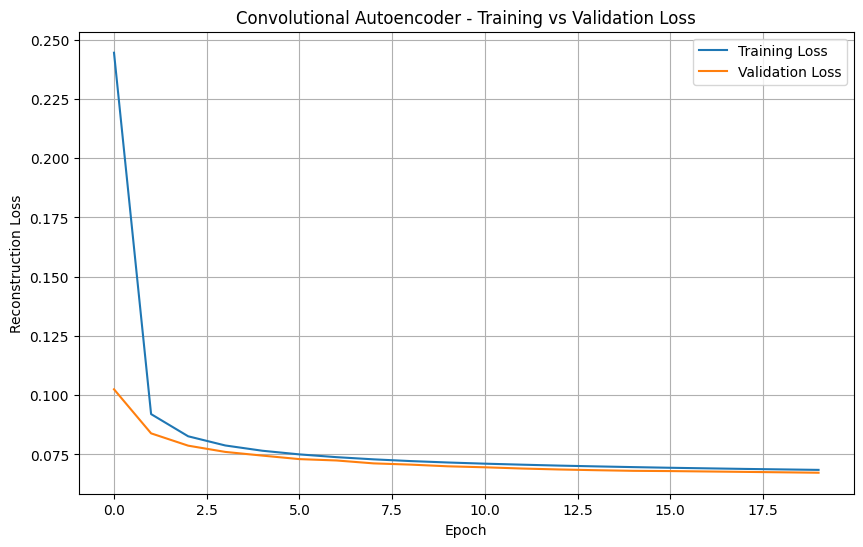

In [ ]:
# ============================================================
# PART 11: CAE TRAINING AND VALIDATION LOSS
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    cae_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    cae_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss")
plt.title("Convolutional Autoencoder - Training vs Validation Loss")

plt.legend()
plt.grid(True)
plt.show()

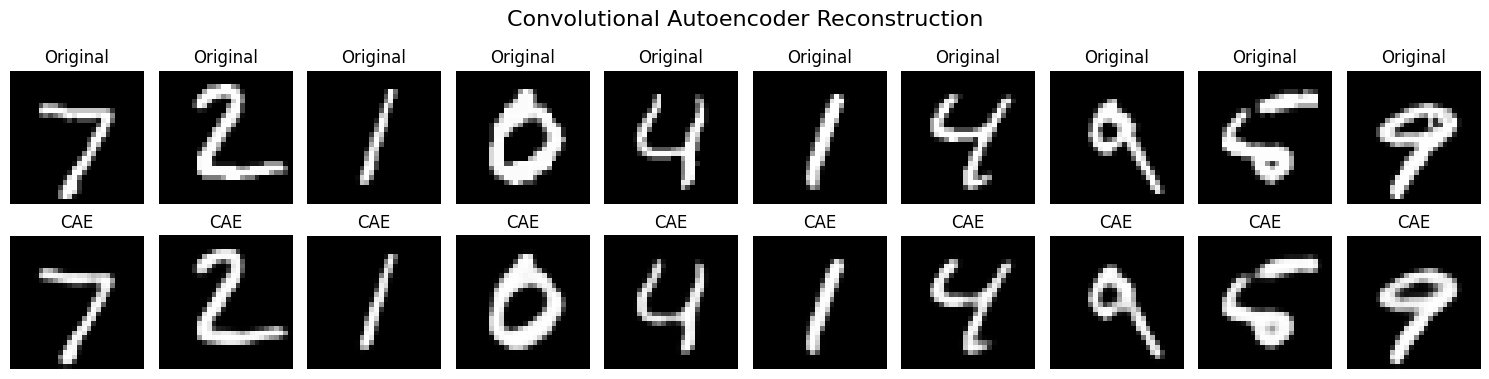

In [ ]:
# ============================================================
# PART 12: CAE RECONSTRUCTIONS
# ============================================================

cae_reconstructed = cae_autoencoder.predict(
    x_test,
    batch_size=128,
    verbose=0
)

n = 10

plt.figure(figsize=(15, 4))

for i in range(n):

    plt.subplot(2, n, i + 1)

    plt.imshow(
        x_test[i].squeeze(),
        cmap="gray"
    )

    plt.title("Original")
    plt.axis("off")

    plt.subplot(2, n, i + 1 + n)

    plt.imshow(
        cae_reconstructed[i].squeeze(),
        cmap="gray"
    )

    plt.title("CAE")
    plt.axis("off")

plt.suptitle(
    "Convolutional Autoencoder Reconstruction",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# PART 13: CAE METRICS
# ============================================================

cae_mse, cae_mae, cae_ssim = calculate_metrics(
    x_test,
    cae_reconstructed
)

print("======================================")
print("CONVOLUTIONAL AUTOENCODER RESULTS")
print("======================================")

print(f"MSE        : {cae_mse:.6f}")
print(f"MAE        : {cae_mae:.6f}")
print(f"SSIM       : {cae_ssim:.6f}")
print(
    f"Parameters : "
    f"{cae_autoencoder.count_params():,}"
)
print(
    f"Training Time : "
    f"{cae_training_time:.2f} seconds"
)

CONVOLUTIONAL AUTOENCODER RESULTS
MSE        : 0.002635
MAE        : 0.015328
SSIM       : 0.972255
Parameters : 74,497
Training Time : 687.11 seconds


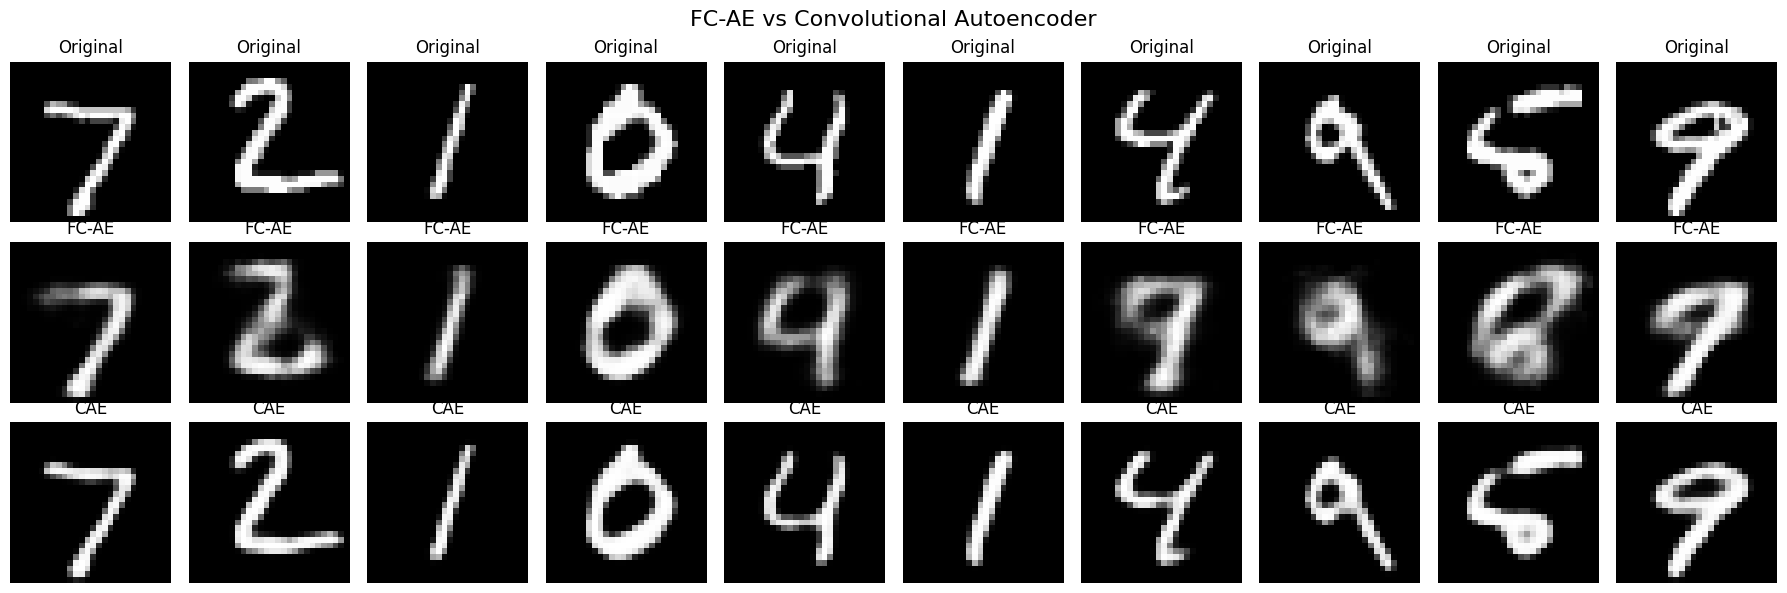

In [ ]:
# ============================================================
# PART 14: FC-AE VS CAE RECONSTRUCTION
# ============================================================

n = 10

plt.figure(figsize=(18, 6))

for i in range(n):

    # Original
    plt.subplot(3, n, i + 1)

    plt.imshow(
        x_test[i].squeeze(),
        cmap="gray"
    )

    plt.title("Original")
    plt.axis("off")

    # FC-AE
    plt.subplot(3, n, i + 1 + n)

    plt.imshow(
        fc_reconstructed[i].squeeze(),
        cmap="gray"
    )

    plt.title("FC-AE")
    plt.axis("off")

    # CAE
    plt.subplot(3, n, i + 1 + 2*n)

    plt.imshow(
        cae_reconstructed[i].squeeze(),
        cmap="gray"
    )

    plt.title("CAE")
    plt.axis("off")

plt.suptitle(
    "FC-AE vs Convolutional Autoencoder",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# PART 15: FC-AE VS CAE RESULTS TABLE
# ============================================================

comparison_basic = pd.DataFrame({
    "Model": [
        "Fully Connected AE",
        "Convolutional AE"
    ],

    "MSE": [
        fc_mse,
        cae_mse
    ],

    "MAE": [
        fc_mae,
        cae_mae
    ],

    "SSIM": [
        fc_ssim,
        cae_ssim
    ],

    "Parameters": [
        fc_autoencoder.count_params(),
        cae_autoencoder.count_params()
    ],

    "Time (seconds)": [
        fc_training_time,
        cae_training_time
    ]
})

comparison_basic

,Model,MSE,MAE,SSIM,Parameters,Time (seconds)
0,Fully Connected AE,0.024054,0.062523,0.715698,211040,22.597244
1,Convolutional AE,0.002635,0.015328,0.972255,74497,687.111243


In [ ]:
# ============================================================
# PART 16: GAUSSIAN NOISE FUNCTION
# ============================================================

def add_gaussian_noise(images, sigma):

    noise = np.random.normal(
        loc=0.0,
        scale=sigma,
        size=images.shape
    )

    noisy_images = images + noise

    noisy_images = np.clip(
        noisy_images,
        0.0,
        1.0
    )

    return noisy_images.astype("float32")


# Test noise
x_test_gaussian_01 = add_gaussian_noise(
    x_test,
    0.1
)

x_test_gaussian_02 = add_gaussian_noise(
    x_test,
    0.2
)

x_test_gaussian_03 = add_gaussian_noise(
    x_test,
    0.3
)

print("Gaussian noisy data created.")

Gaussian noisy data created.


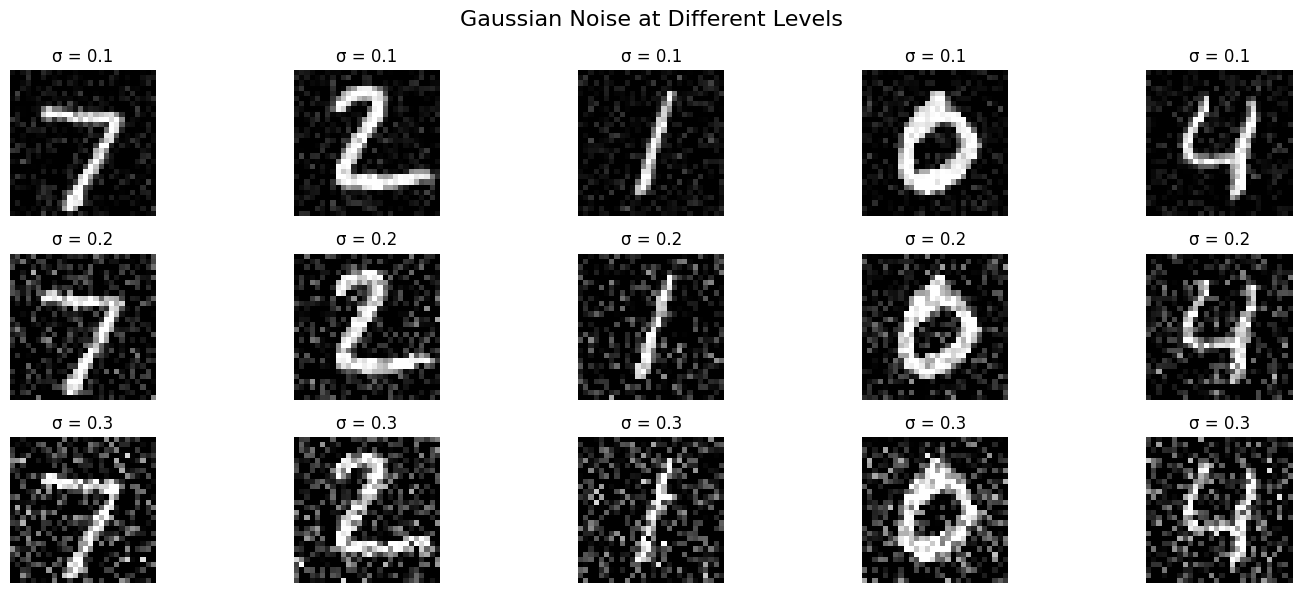

In [ ]:
# ============================================================
# PART 17: GAUSSIAN NOISE VISUALIZATION
# ============================================================

noise_levels = [0.1, 0.2, 0.3]

noisy_versions = [
    x_test_gaussian_01,
    x_test_gaussian_02,
    x_test_gaussian_03
]

plt.figure(figsize=(15, 6))

for row, (sigma, noisy_images) in enumerate(
    zip(noise_levels, noisy_versions)
):

    for i in range(5):

        plt.subplot(
            3,
            5,
            row * 5 + i + 1
        )

        plt.imshow(
            noisy_images[i].squeeze(),
            cmap="gray"
        )

        plt.title(f"σ = {sigma}")
        plt.axis("off")

plt.suptitle(
    "Gaussian Noise at Different Levels",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# PART 18: SALT-AND-PEPPER NOISE
# ============================================================

def add_salt_pepper_noise(images, probability):

    noisy = images.copy()

    random_values = np.random.random(
        size=images.shape
    )

    # Salt pixels -> 1
    salt_mask = random_values < (probability / 2)

    # Pepper pixels -> 0
    pepper_mask = (
        random_values >= (probability / 2)
    ) & (
        random_values < probability
    )

    noisy[salt_mask] = 1.0
    noisy[pepper_mask] = 0.0

    return noisy.astype("float32")


sp_levels = [0.05, 0.10, 0.20]

sp_images = [
    add_salt_pepper_noise(
        x_test,
        p
    )
    for p in sp_levels
]

print("Salt-and-pepper noisy images created.")

Salt-and-pepper noisy images created.


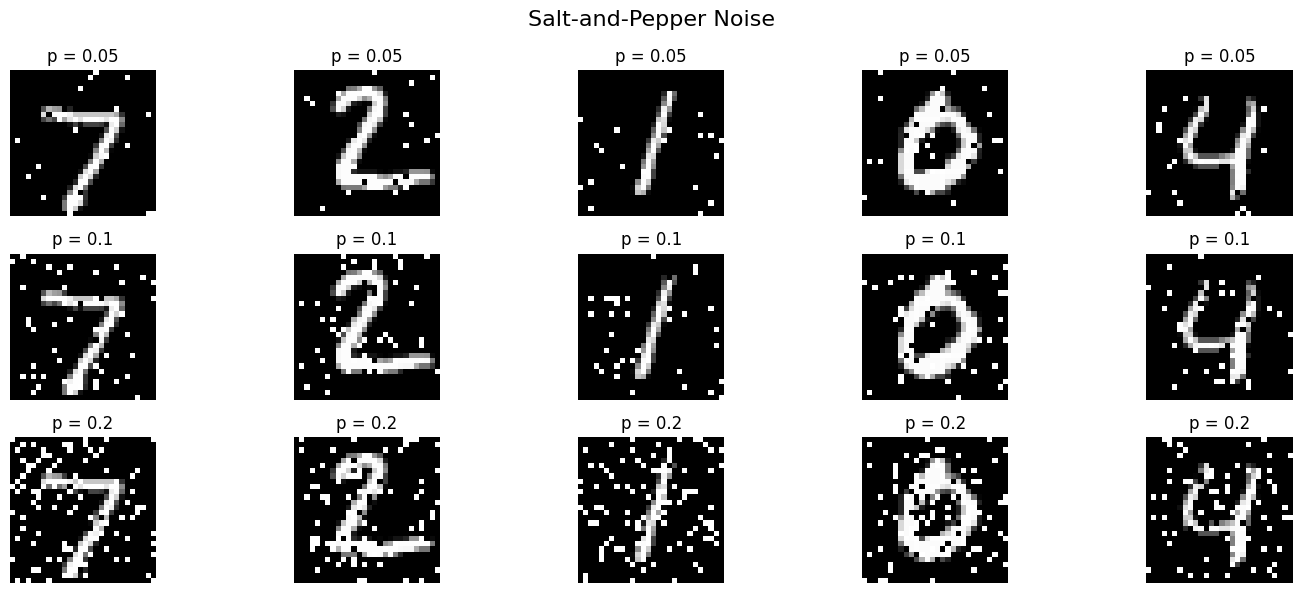

In [ ]:
# ============================================================
# PART 19: SALT-AND-PEPPER VISUALIZATION
# ============================================================

plt.figure(figsize=(15, 6))

for row, (p, noisy_images) in enumerate(
    zip(sp_levels, sp_images)
):

    for i in range(5):

        plt.subplot(
            3,
            5,
            row * 5 + i + 1
        )

        plt.imshow(
            noisy_images[i].squeeze(),
            cmap="gray"
        )

        plt.title(f"p = {p}")
        plt.axis("off")

plt.suptitle(
    "Salt-and-Pepper Noise",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# PART 20: DENOISING CONVOLUTIONAL AUTOENCODER
# ============================================================

def build_denoising_cae():

    inputs = keras.Input(
        shape=(28, 28, 1)
    )

    # -------------------------
    # Encoder
    # -------------------------

    x = layers.Conv2D(
        32,
        3,
        activation="relu",
        padding="same"
    )(inputs)

    x = layers.MaxPooling2D(
        2,
        padding="same"
    )(x)

    x = layers.Conv2D(
        64,
        3,
        activation="relu",
        padding="same"
    )(x)

    x = layers.MaxPooling2D(
        2,
        padding="same"
    )(x)

    x = layers.Conv2D(
        64,
        3,
        activation="relu",
        padding="same"
    )(x)

    # -------------------------
    # Decoder
    # -------------------------

    x = layers.UpSampling2D(2)(x)

    x = layers.Conv2D(
        32,
        3,
        activation="relu",
        padding="same"
    )(x)

    x = layers.UpSampling2D(2)(x)

    outputs = layers.Conv2D(
        1,
        3,
        activation="sigmoid",
        padding="same"
    )(x)

    model = Model(
        inputs,
        outputs,
        name="Denoising_CAE"
    )

    return model


denoising_cae = build_denoising_cae()

denoising_cae.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="binary_crossentropy"
)

denoising_cae.summary()

Model: "Denoising_CAE"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================================
# PART 21: TRAIN DENOISING CAE
# ============================================================

train_sigma = 0.2

x_train_noisy = add_gaussian_noise(
    x_train,
    train_sigma
)

start_time = time.time()

denoise_history = denoising_cae.fit(
    x_train_noisy,
    x_train,

    validation_data=(
        x_test_gaussian_02,
        x_test
    ),

    epochs=20,
    batch_size=128,

    shuffle=True,
    verbose=1
)

denoising_training_time = (
    time.time() - start_time
)

print(
    f"\nDenoising CAE Training Time: "
    f"{denoising_training_time:.2f} seconds"
)

Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 29s 345ms/step - loss: 0.2686 - val_loss: 0.1245
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 28s 350ms/step - loss: 0.1072 - val_loss: 0.0953
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 41s 355ms/step - loss: 0.0930 - val_loss: 0.0883
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 41s 350ms/step - loss: 0.0878 - val_loss: 0.0850
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 41s 348ms/step - loss: 0.0848 - val_loss: 0.0822
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 40s 342ms/step - loss: 0.0825 - val_loss: 0.0800
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 27s 345ms/step - loss: 0.0807 - val_loss: 0.0785
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 27s 345ms/step - loss: 0.0796 - val_loss: 0.0776
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 41s 342ms/step - loss: 0.0787 - val_loss: 0.0769
Epoch 10/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 27s 340ms/step - loss: 0.0780 - val_loss: 0.0764
Epoch 11/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 41s 344ms/step - loss: 0.0774 - val_loss: 0.0759
Epoch 12/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 27

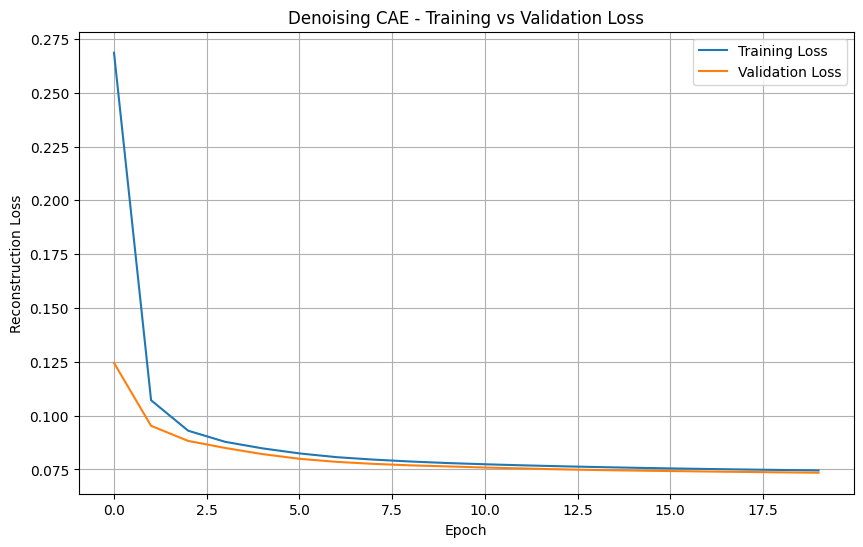

In [ ]:
# ============================================================
# PART 22: DENOISING CAE LOSS
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    denoise_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    denoise_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss")

plt.title(
    "Denoising CAE - Training vs Validation Loss"
)

plt.legend()
plt.grid(True)
plt.show()

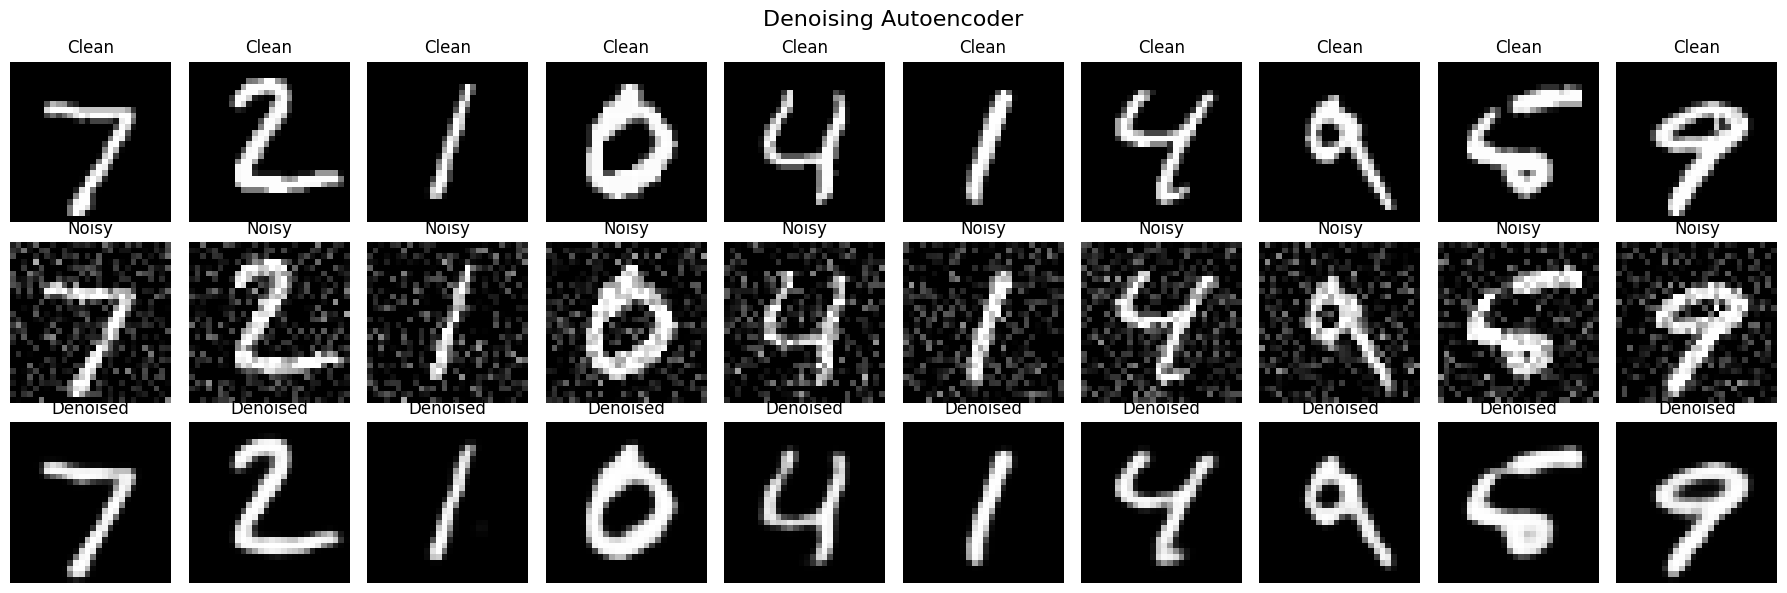

In [ ]:
# ============================================================
# PART 23: CLEAN VS NOISY VS DENOISED
# ============================================================

denoised_test = denoising_cae.predict(
    x_test_gaussian_02,
    batch_size=128,
    verbose=0
)

n = 10

plt.figure(figsize=(18, 6))

for i in range(n):

    # Clean
    plt.subplot(3, n, i + 1)

    plt.imshow(
        x_test[i].squeeze(),
        cmap="gray"
    )

    plt.title("Clean")
    plt.axis("off")

    # Noisy
    plt.subplot(3, n, i + 1 + n)

    plt.imshow(
        x_test_gaussian_02[i].squeeze(),
        cmap="gray"
    )

    plt.title("Noisy")
    plt.axis("off")

    # Denoised
    plt.subplot(3, n, i + 1 + 2*n)

    plt.imshow(
        denoised_test[i].squeeze(),
        cmap="gray"
    )

    plt.title("Denoised")
    plt.axis("off")

plt.suptitle(
    "Denoising Autoencoder",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# PART 24: NOISE LEVEL VS RECONSTRUCTION QUALITY
# ============================================================

noise_results = []

for sigma in [0.1, 0.2, 0.3]:

    noisy_test = add_gaussian_noise(
        x_test,
        sigma
    )

    denoised = denoising_cae.predict(
        noisy_test,
        batch_size=128,
        verbose=0
    )

    mse, mae, ssim_score = calculate_metrics(
        x_test,
        denoised
    )

    noise_results.append({
        "Gaussian Sigma": sigma,
        "MSE": mse,
        "MAE": mae,
        "SSIM": ssim_score
    })


noise_results_df = pd.DataFrame(
    noise_results
)

print("DENOISING PERFORMANCE")
display(noise_results_df)

DENOISING PERFORMANCE


,Gaussian Sigma,MSE,MAE,SSIM
0,0.1,0.003476,0.017305,0.961541
1,0.2,0.004490,0.020850,0.945626
2,0.3,0.006890,0.029002,0.863830


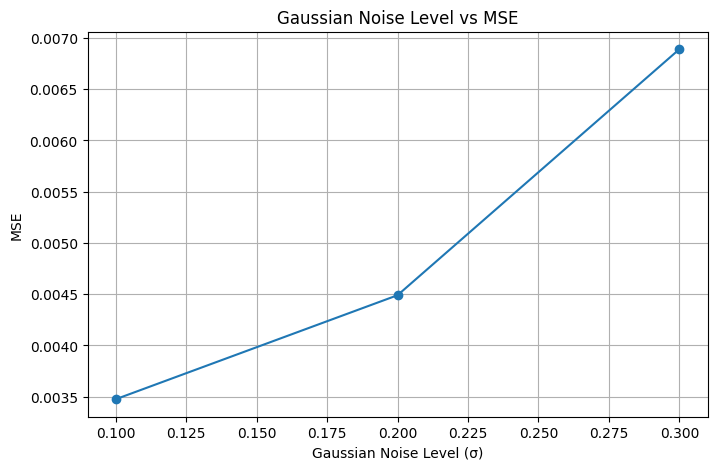

In [ ]:
# ============================================================
# PART 25: NOISE LEVEL VS MSE
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    noise_results_df["Gaussian Sigma"],
    noise_results_df["MSE"],
    marker="o"
)

plt.xlabel("Gaussian Noise Level (σ)")
plt.ylabel("MSE")

plt.title(
    "Gaussian Noise Level vs MSE"
)

plt.grid(True)
plt.show()

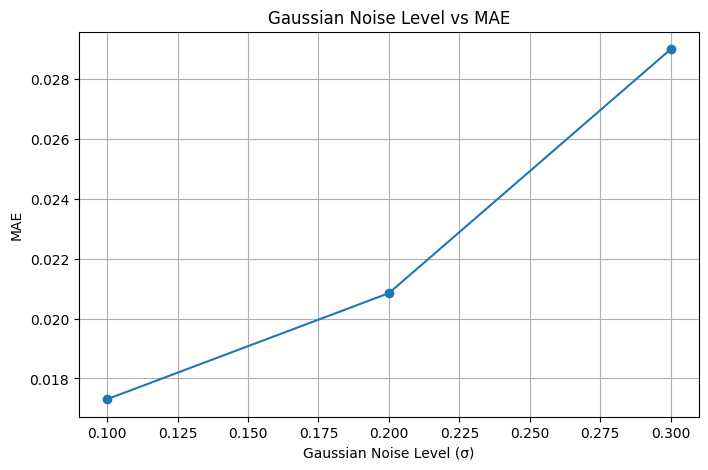

In [ ]:
# ============================================================
# PART 26: NOISE LEVEL VS MAE
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    noise_results_df["Gaussian Sigma"],
    noise_results_df["MAE"],
    marker="o"
)

plt.xlabel("Gaussian Noise Level (σ)")
plt.ylabel("MAE")

plt.title(
    "Gaussian Noise Level vs MAE"
)

plt.grid(True)
plt.show()

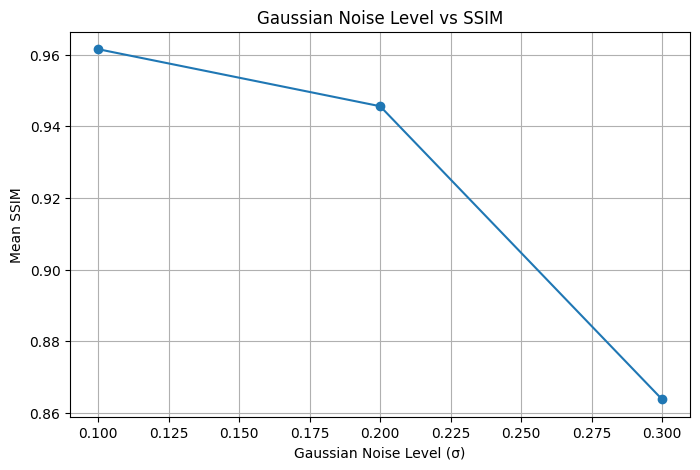

In [ ]:
# ============================================================
# PART 27: NOISE LEVEL VS SSIM
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    noise_results_df["Gaussian Sigma"],
    noise_results_df["SSIM"],
    marker="o"
)

plt.xlabel("Gaussian Noise Level (σ)")
plt.ylabel("Mean SSIM")

plt.title(
    "Gaussian Noise Level vs SSIM"
)

plt.grid(True)
plt.show()

In [ ]:
# ============================================================
# PART 28: VARIATIONAL AUTOENCODER
# ============================================================

latent_dim_vae = 2


# ------------------------------------------------------------
# Sampling Layer
# ------------------------------------------------------------

class Sampling(layers.Layer):

    def call(self, inputs):

        z_mean, z_log_var = inputs

        batch = tf.shape(z_mean)[0]

        dim = tf.shape(z_mean)[1]

        epsilon = tf.random.normal(
            shape=(batch, dim)
        )

        return (
            z_mean
            + tf.exp(0.5 * z_log_var)
            * epsilon
        )


# ------------------------------------------------------------
# VAE Encoder
# ------------------------------------------------------------

vae_encoder_inputs = keras.Input(
    shape=(28, 28, 1),
    name="VAE_Encoder_Input"
)

x = layers.Conv2D(
    32,
    3,
    activation="relu",
    strides=2,
    padding="same"
)(vae_encoder_inputs)

x = layers.Conv2D(
    64,
    3,
    activation="relu",
    strides=2,
    padding="same"
)(x)

x = layers.Flatten()(x)

x = layers.Dense(
    128,
    activation="relu"
)(x)

z_mean = layers.Dense(
    latent_dim_vae,
    name="z_mean"
)(x)

z_log_var = layers.Dense(
    latent_dim_vae,
    name="z_log_var"
)(x)

z = Sampling()(
    [z_mean, z_log_var]
)

vae_encoder = Model(
    vae_encoder_inputs,
    [z_mean, z_log_var, z],
    name="VAE_Encoder"
)

vae_encoder.summary()

Model: "VAE_Encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ VAE_Encoder_Input   │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 14, 14,    │        320 │ VAE_Encoder_Inpu… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 7, 7, 64)  │     18,496 │ conv2d_10[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 3136)      │          0 │ conv2d_11[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 128)       │    401,536 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │        258 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │        258 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Sampling) │ (None, 2)         │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 420,868 (1.61 MB)

 Trainable params: 420,868 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================================
# PART 29: VAE DECODER
# ============================================================

latent_inputs = keras.Input(
    shape=(latent_dim_vae,),
    name="VAE_Latent_Input"
)

x = layers.Dense(
    7 * 7 * 64,
    activation="relu"
)(latent_inputs)

x = layers.Reshape(
    (7, 7, 64)
)(x)

x = layers.Conv2DTranspose(
    64,
    3,
    activation="relu",
    strides=2,
    padding="same"
)(x)

x = layers.Conv2DTranspose(
    32,
    3,
    activation="relu",
    strides=2,
    padding="same"
)(x)

vae_decoder_outputs = layers.Conv2DTranspose(
    1,
    3,
    activation="sigmoid",
    padding="same"
)(x)

vae_decoder = Model(
    latent_inputs,
    vae_decoder_outputs,
    name="VAE_Decoder"
)

vae_decoder.summary()

Model: "VAE_Decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ VAE_Latent_Input (InputLayer)   │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3136)           │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │           289 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,089 (254.25 KB)

 Trainable params: 65,089 (254.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================================
# PART 30: COMPLETE VAE
# ============================================================

class VAE(Model):

    def __init__(
        self,
        encoder,
        decoder,
        **kwargs
    ):

        super().__init__(**kwargs)

        self.encoder = encoder
        self.decoder = decoder

        self.total_loss_tracker = (
            keras.metrics.Mean(
                name="total_loss"
            )
        )

        self.reconstruction_loss_tracker = (
            keras.metrics.Mean(
                name="reconstruction_loss"
            )
        )

        self.kl_loss_tracker = (
            keras.metrics.Mean(
                name="kl_loss"
            )
        )

    @property
    def metrics(self):

        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker
        ]

    def train_step(self, data):

        # Handle possible tuple format
        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:

            z_mean, z_log_var, z = (
                self.encoder(data)
            )

            reconstruction = (
                self.decoder(z)
            )

            # Reconstruction loss
            reconstruction_loss = (
                tf.reduce_mean(
                    tf.reduce_sum(
                        keras.losses.binary_crossentropy(
                            data,
                            reconstruction
                        ),
                        axis=(1, 2)
                    )
                )
            )

            # KL divergence
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1
                    + z_log_var
                    - tf.square(z_mean)
                    - tf.exp(z_log_var),
                    axis=1
                )
            )

            # Total VAE loss
            total_loss = (
                reconstruction_loss
                + kl_loss
            )

        grads = tape.gradient(
            total_loss,
            self.trainable_weights
        )

        self.optimizer.apply_gradients(
            zip(
                grads,
                self.trainable_weights
            )
        )

        self.total_loss_tracker.update_state(
            total_loss
        )

        self.reconstruction_loss_tracker.update_state(
            reconstruction_loss
        )

        self.kl_loss_tracker.update_state(
            kl_loss
        )

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss":
                self.reconstruction_loss_tracker.result(),
            "kl_loss":
                self.kl_loss_tracker.result()
        }

    def test_step(self, data):

        if isinstance(data, tuple):
            data = data[0]

        z_mean, z_log_var, z = (
            self.encoder(data)
        )

        reconstruction = (
            self.decoder(z)
        )

        reconstruction_loss = (
            tf.reduce_mean(
                tf.reduce_sum(
                    keras.losses.binary_crossentropy(
                        data,
                        reconstruction
                    ),
                    axis=(1, 2)
                )
            )
        )

        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(
                1
                + z_log_var
                - tf.square(z_mean)
                - tf.exp(z_log_var),
                axis=1
            )
        )

        total_loss = (
            reconstruction_loss
            + kl_loss
        )

        self.total_loss_tracker.update_state(
            total_loss
        )

        self.reconstruction_loss_tracker.update_state(
            reconstruction_loss
        )

        self.kl_loss_tracker.update_state(
            kl_loss
        )

        return {
            "loss":
                self.total_loss_tracker.result(),

            "reconstruction_loss":
                self.reconstruction_loss_tracker.result(),

            "kl_loss":
                self.kl_loss_tracker.result()
        }


vae = VAE(
    vae_encoder,
    vae_decoder,
    name="VAE"
)

vae.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-3
    )
)

print("VAE created successfully.")

VAE created successfully.


In [ ]:
# ============================================================
# PART 31: TRAIN VAE
# ============================================================

start_time = time.time()

vae_history = vae.fit(
    x_train,
    x_train,

    validation_data=(
        x_test,
        x_test
    ),

    epochs=20,
    batch_size=128,

    shuffle=True,
    verbose=1
)

vae_training_time = time.time() - start_time

print(
    f"\nVAE Training Time: "
    f"{vae_training_time:.2f} seconds"
)

Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 18s 188ms/step - kl_loss: 5.2185 - loss: 294.6598 - reconstruction_loss: 289.4413 - val_kl_loss: 4.0095 - val_loss: 202.0429 - val_reconstruction_loss: 198.0334
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 20s 177ms/step - kl_loss: 3.9837 - loss: 202.8748 - reconstruction_loss: 198.8911 - val_kl_loss: 3.9183 - val_loss: 190.0291 - val_reconstruction_loss: 186.1107
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 21s 177ms/step - kl_loss: 4.1122 - loss: 189.9454 - reconstruction_loss: 185.8332 - val_kl_loss: 4.5971 - val_loss: 177.3468 - val_reconstruction_loss: 172.7497
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 20s 176ms/step - kl_loss: 4.4888 - loss: 179.5560 - reconstruction_loss: 175.0671 - val_kl_loss: 4.9763 - val_loss: 170.9783 - val_reconstruction_loss: 166.0020
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 14s 183ms/step - kl_loss: 4.6770 - loss: 173.5823 - reconstruction_loss: 168.9053 - val_kl_loss: 5.3110 - val_loss: 168.7969 - val_reconstruction_loss: 163.4859
Epoch

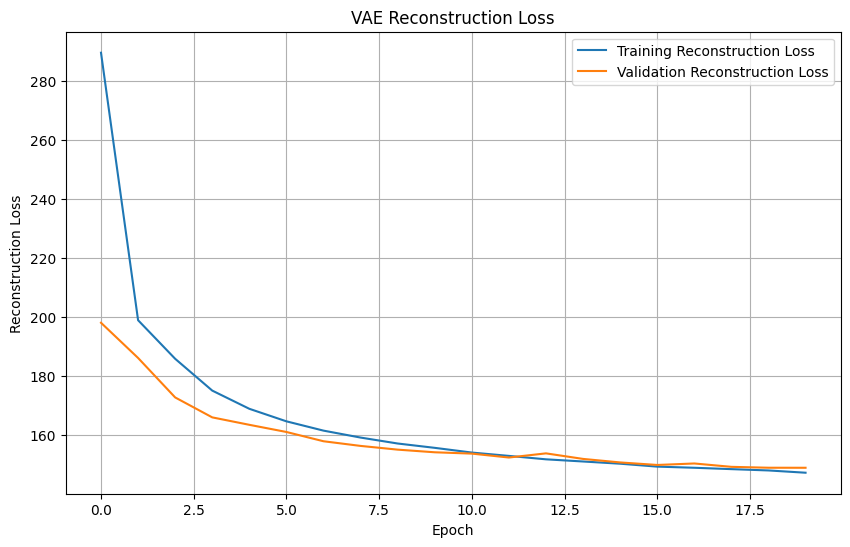

In [ ]:
# ============================================================
# PART 32: VAE TRAINING LOSS
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    vae_history.history["reconstruction_loss"],
    label="Training Reconstruction Loss"
)

plt.plot(
    vae_history.history["val_reconstruction_loss"],
    label="Validation Reconstruction Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss")

plt.title(
    "VAE Reconstruction Loss"
)

plt.legend()
plt.grid(True)
plt.show()

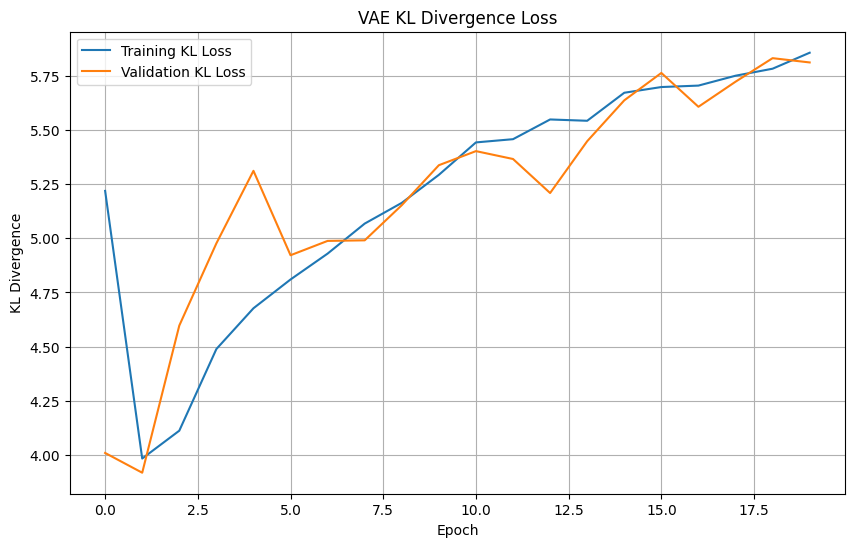

In [ ]:
# ============================================================
# PART 33: VAE KL LOSS
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    vae_history.history["kl_loss"],
    label="Training KL Loss"
)

plt.plot(
    vae_history.history["val_kl_loss"],
    label="Validation KL Loss"
)

plt.xlabel("Epoch")
plt.ylabel("KL Divergence")

plt.title(
    "VAE KL Divergence Loss"
)

plt.legend()
plt.grid(True)
plt.show()

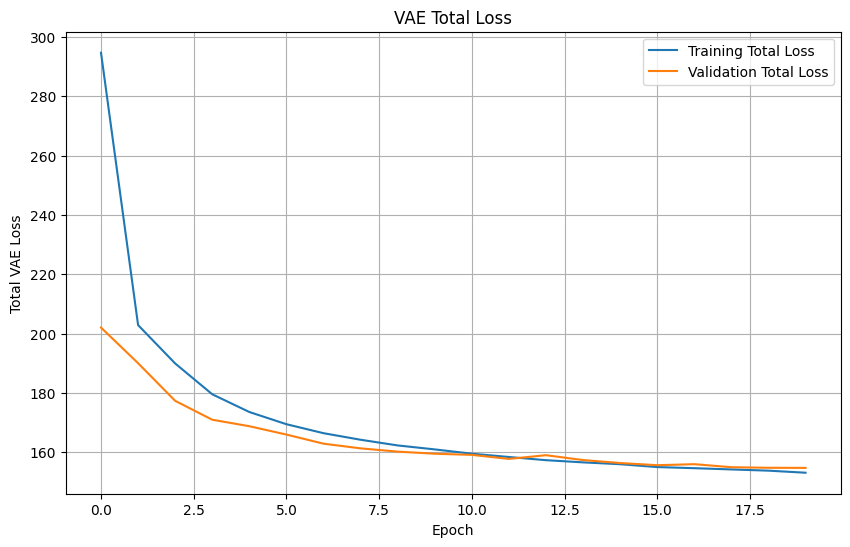

In [ ]:
# ============================================================
# PART 34: VAE TOTAL LOSS
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    vae_history.history["loss"],
    label="Training Total Loss"
)

plt.plot(
    vae_history.history["val_loss"],
    label="Validation Total Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Total VAE Loss")

plt.title(
    "VAE Total Loss"
)

plt.legend()
plt.grid(True)
plt.show()

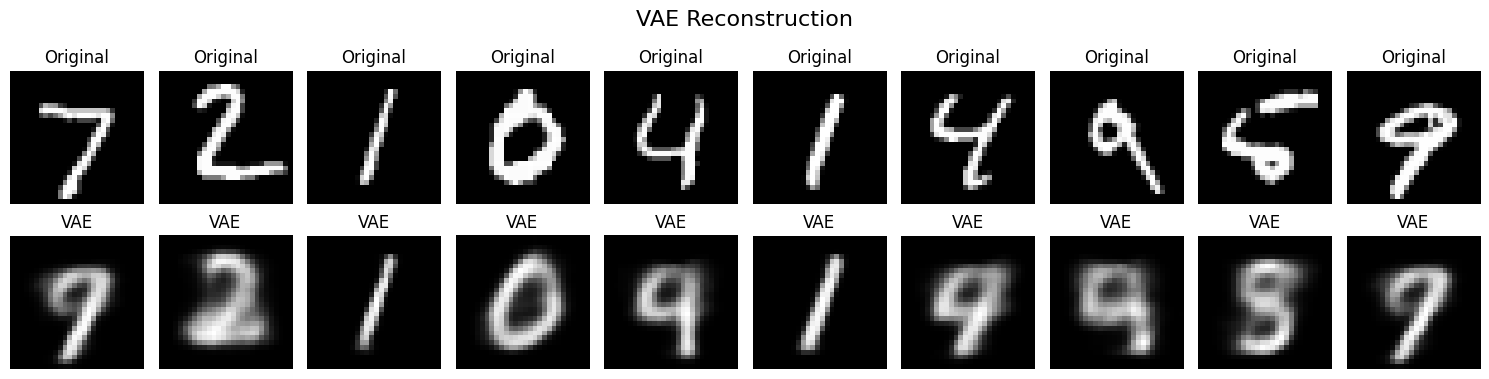

In [ ]:
# ============================================================
# PART 35: VAE RECONSTRUCTION
# ============================================================

z_mean_test, z_log_var_test, z_test = (
    vae_encoder.predict(
        x_test,
        batch_size=128,
        verbose=0
    )
)

vae_reconstructed = (
    vae_decoder.predict(
        z_test,
        batch_size=128,
        verbose=0
    )
)

n = 10

plt.figure(figsize=(15, 4))

for i in range(n):

    plt.subplot(2, n, i + 1)

    plt.imshow(
        x_test[i].squeeze(),
        cmap="gray"
    )

    plt.title("Original")
    plt.axis("off")

    plt.subplot(
        2,
        n,
        i + 1 + n
    )

    plt.imshow(
        vae_reconstructed[i].squeeze(),
        cmap="gray"
    )

    plt.title("VAE")
    plt.axis("off")

plt.suptitle(
    "VAE Reconstruction",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# PART 36: VAE RECONSTRUCTION METRICS - FIXED
# ============================================================

vae_mse, vae_mae, vae_ssim = calculate_metrics(
    x_test,
    vae_reconstructed
)

# Get final validation loss values
vae_reconstruction_loss = (
    vae_history.history[
        "val_reconstruction_loss"
    ][-1]
)

vae_kl_loss = (
    vae_history.history[
        "val_kl_loss"
    ][-1]
)

vae_total_loss = (
    vae_history.history[
        "val_loss"
    ][-1]
)

# ------------------------------------------------------------
# Calculate VAE parameters manually
# ------------------------------------------------------------
#
# The custom VAE wrapper itself is not built, so
# vae.count_params() causes the ValueError.
#
# Encoder + Decoder are already built.
# ------------------------------------------------------------

vae_parameters = (
    vae_encoder.count_params()
    + vae_decoder.count_params()
)

print("======================================")
print("VARIATIONAL AUTOENCODER RESULTS")
print("======================================")

print(
    f"Reconstruction Loss : "
    f"{vae_reconstruction_loss:.6f}"
)

print(
    f"KL Loss             : "
    f"{vae_kl_loss:.6f}"
)

print(
    f"Total Loss          : "
    f"{vae_total_loss:.6f}"
)

print(
    f"Test MSE            : "
    f"{vae_mse:.6f}"
)

print(
    f"Test MAE            : "
    f"{vae_mae:.6f}"
)

print(
    f"Mean SSIM           : "
    f"{vae_ssim:.6f}"
)

print(
    f"Parameters          : "
    f"{vae_parameters:,}"
)

print(
    f"Training Time       : "
    f"{vae_training_time:.2f} seconds"
)

VARIATIONAL AUTOENCODER RESULTS
Reconstruction Loss : 148.942459
KL Loss             : 5.810935
Total Loss          : 154.753403
Test MSE            : 0.043744
Test MAE            : 0.101763
Mean SSIM           : 0.488105
Parameters          : 485,957
Training Time       : 357.25 seconds


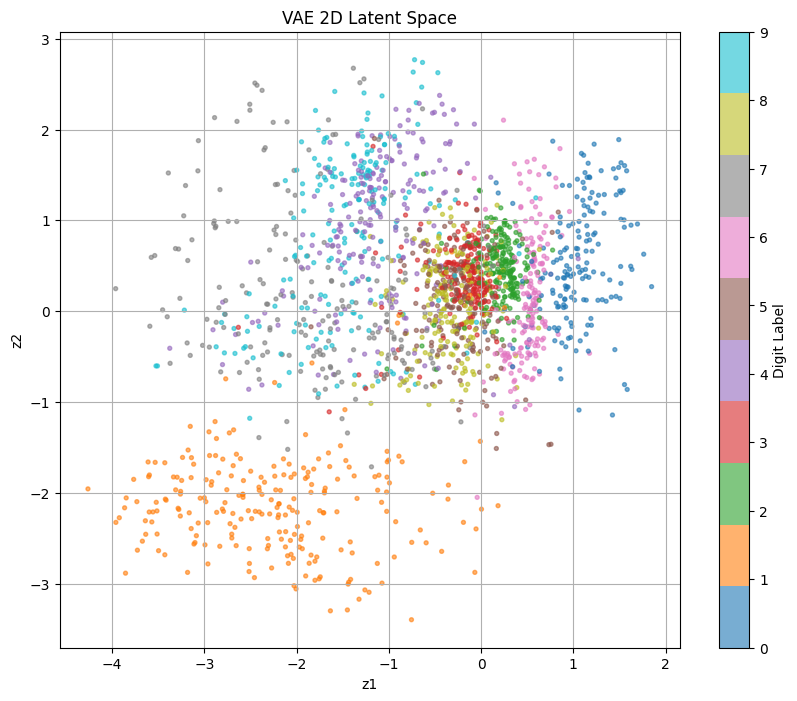

In [ ]:
# ============================================================
# PART 37: VAE LATENT SPACE VISUALIZATION
# ============================================================

plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    z_mean_test[:, 0],
    z_mean_test[:, 1],
    c=y_test,
    cmap="tab10",
    s=8,
    alpha=0.6
)

plt.xlabel("z1")
plt.ylabel("z2")

plt.title(
    "VAE 2D Latent Space"
)

plt.colorbar(
    scatter,
    label="Digit Label"
)

plt.grid(True)
plt.show()

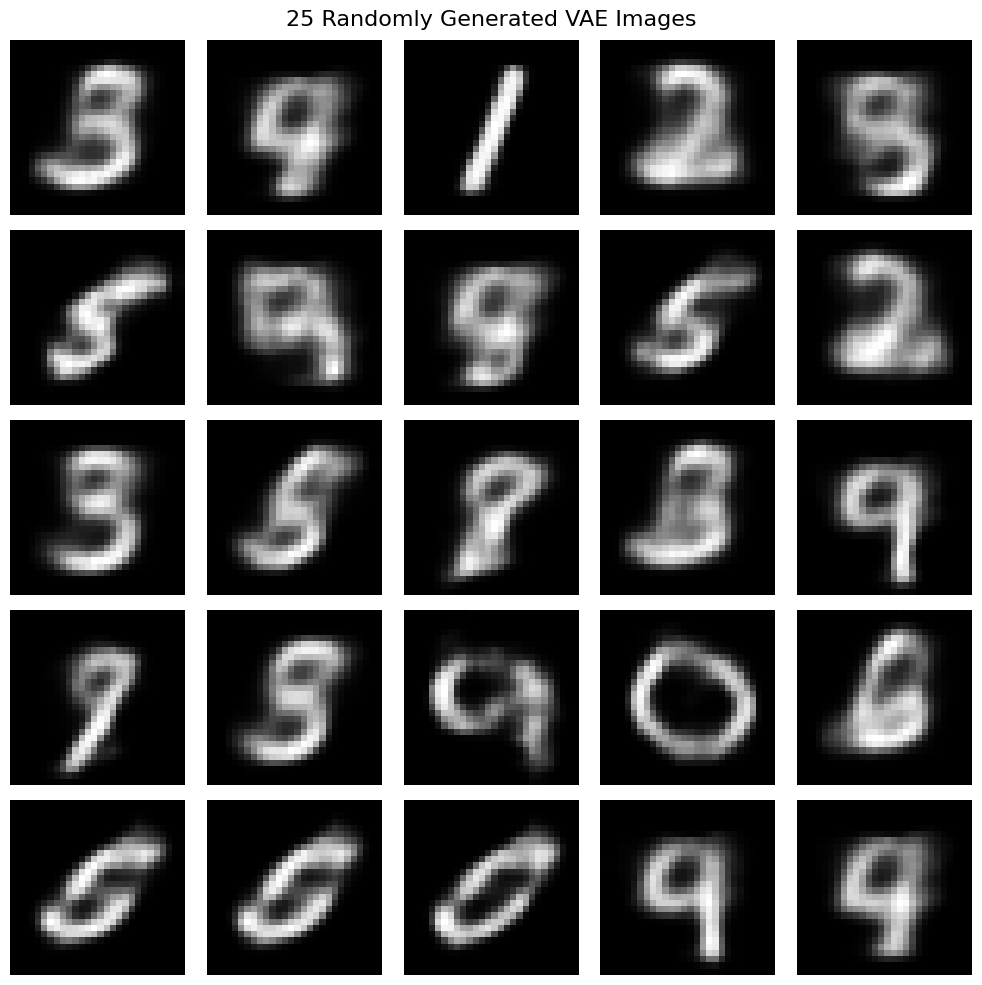

In [ ]:
# ============================================================
# PART 38: VAE RANDOM IMAGE GENERATION
# ============================================================

num_generated = 25

random_latent_vectors = np.random.normal(
    size=(num_generated, latent_dim_vae)
)

generated_images = (
    vae_decoder.predict(
        random_latent_vectors,
        verbose=0
    )
)

plt.figure(figsize=(10, 10))

for i in range(num_generated):

    plt.subplot(5, 5, i + 1)

    plt.imshow(
        generated_images[i].squeeze(),
        cmap="gray"
    )

    plt.axis("off")

plt.suptitle(
    "25 Randomly Generated VAE Images",
    fontsize=16
)

plt.tight_layout()
plt.show()

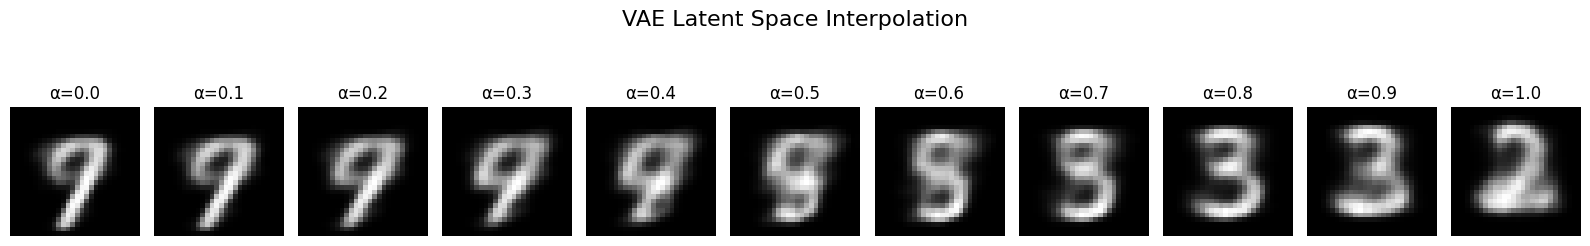

In [ ]:
# ============================================================
# PART 39: LATENT SPACE INTERPOLATION
# ============================================================

# Select two latent vectors
zA = z_mean_test[0]
zB = z_mean_test[1]

# Alpha values
alphas = np.linspace(
    0,
    1,
    11
)

interpolated_vectors = []

for alpha in alphas:

    z_interpolated = (
        (1 - alpha) * zA
        + alpha * zB
    )

    interpolated_vectors.append(
        z_interpolated
    )

interpolated_vectors = np.array(
    interpolated_vectors
)

# Decode
interpolated_images = (
    vae_decoder.predict(
        interpolated_vectors,
        verbose=0
    )
)

# Display
plt.figure(figsize=(16, 3))

for i in range(len(alphas)):

    plt.subplot(
        1,
        len(alphas),
        i + 1
    )

    plt.imshow(
        interpolated_images[i].squeeze(),
        cmap="gray"
    )

    plt.title(
        f"α={alphas[i]:.1f}"
    )

    plt.axis("off")

plt.suptitle(
    "VAE Latent Space Interpolation",
    fontsize=16
)

plt.tight_layout()
plt.show()

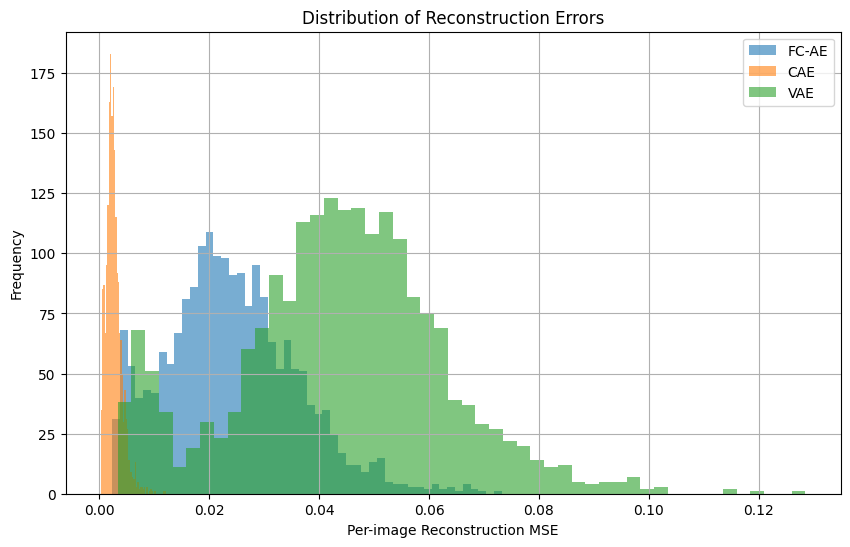

In [ ]:
# ============================================================
# PART 40: RECONSTRUCTION ERROR DISTRIBUTION
# ============================================================

# Per-image MSE
fc_image_errors = np.mean(
    (x_test - fc_reconstructed) ** 2,
    axis=(1, 2, 3)
)

cae_image_errors = np.mean(
    (x_test - cae_reconstructed) ** 2,
    axis=(1, 2, 3)
)

denoise_image_errors = np.mean(
    (x_test - denoised_test) ** 2,
    axis=(1, 2, 3)
)

vae_image_errors = np.mean(
    (x_test - vae_reconstructed) ** 2,
    axis=(1, 2, 3)
)


plt.figure(figsize=(10, 6))

plt.hist(
    fc_image_errors,
    bins=50,
    alpha=0.6,
    label="FC-AE"
)

plt.hist(
    cae_image_errors,
    bins=50,
    alpha=0.6,
    label="CAE"
)

plt.hist(
    vae_image_errors,
    bins=50,
    alpha=0.6,
    label="VAE"
)

plt.xlabel(
    "Per-image Reconstruction MSE"
)

plt.ylabel("Frequency")

plt.title(
    "Distribution of Reconstruction Errors"
)

plt.legend()
plt.grid(True)
plt.show()

Top 5 high-error test image indices:
[ 895 1526 1969 1125 1320]

Corresponding digit labels:
[0 0 6 8 8]


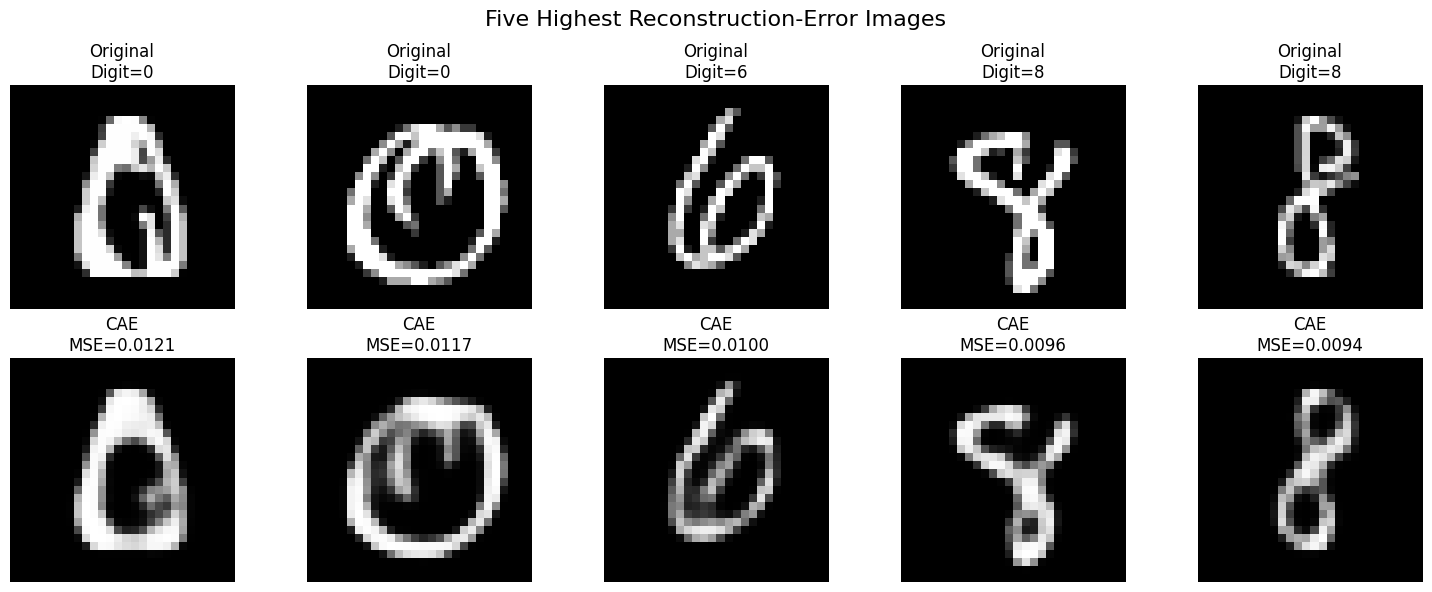

In [ ]:
# ============================================================
# PART 41: TOP 5 HIGH-ERROR IMAGES
# ============================================================

# Use CAE for high-error analysis
high_error_indices = np.argsort(
    cae_image_errors
)[-5:][::-1]

print(
    "Top 5 high-error test image indices:"
)

print(high_error_indices)

print(
    "\nCorresponding digit labels:"
)

print(
    y_test[high_error_indices]
)


plt.figure(figsize=(15, 6))

for position, idx in enumerate(
    high_error_indices
):

    # Original
    plt.subplot(
        2,
        5,
        position + 1
    )

    plt.imshow(
        x_test[idx].squeeze(),
        cmap="gray"
    )

    plt.title(
        f"Original\nDigit={y_test[idx]}"
    )

    plt.axis("off")

    # Reconstruction
    plt.subplot(
        2,
        5,
        position + 6
    )

    plt.imshow(
        cae_reconstructed[idx].squeeze(),
        cmap="gray"
    )

    plt.title(
        f"CAE\nMSE={cae_image_errors[idx]:.4f}"
    )

    plt.axis("off")

plt.suptitle(
    "Five Highest Reconstruction-Error Images",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# PART 42: FINAL MODEL COMPARISON - FIXED
# ============================================================

# ------------------------------------------------------------
# Denoising CAE metrics
# ------------------------------------------------------------

denoise_mse, denoise_mae, denoise_ssim = (
    calculate_metrics(
        x_test,
        denoised_test
    )
)


# ------------------------------------------------------------
# VAE parameter count
# ------------------------------------------------------------
# The custom VAE wrapper is not built.
# Count encoder + decoder parameters instead.
# ------------------------------------------------------------

vae_parameters = (
    vae_encoder.count_params()
    + vae_decoder.count_params()
)


# ------------------------------------------------------------
# Final comparison table
# ------------------------------------------------------------

final_results = pd.DataFrame({

    "Model": [
        "FC Autoencoder",
        "Convolutional AE",
        "Denoising CAE",
        "VAE"
    ],

    "MSE": [
        fc_mse,
        cae_mse,
        denoise_mse,
        vae_mse
    ],

    "MAE": [
        fc_mae,
        cae_mae,
        denoise_mae,
        vae_mae
    ],

    "SSIM": [
        fc_ssim,
        cae_ssim,
        denoise_ssim,
        vae_ssim
    ],

    "Parameters": [
        fc_autoencoder.count_params(),
        cae_autoencoder.count_params(),
        denoising_cae.count_params(),
        vae_parameters
    ],

    "Time (seconds)": [
        fc_training_time,
        cae_training_time,
        denoising_training_time,
        vae_training_time
    ]
})


# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("=" * 80)
print("FINAL MODEL COMPARISON")
print("=" * 80)

display(final_results)

FINAL MODEL COMPARISON


,Model,MSE,MAE,SSIM,Parameters,Time (seconds)
0,FC Autoencoder,0.024054,0.062523,0.715698,211040,22.597244
1,Convolutional AE,0.002635,0.015328,0.972255,74497,687.111243
2,Denoising CAE,0.004466,0.020804,0.945681,74497,682.341479
3,VAE,0.043744,0.101763,0.488105,485957,357.245038


In [ ]:
# ============================================================
# PART 43: VAE LOSS TABLE
# ============================================================

vae_results = pd.DataFrame({

    "Metric": [
        "Reconstruction Loss",
        "KL Loss",
        "Total Loss",
        "Test MSE",
        "Test MAE",
        "Mean SSIM"
    ],

    "Value": [
        vae_reconstruction_loss,
        vae_kl_loss,
        vae_total_loss,
        vae_mse,
        vae_mae,
        vae_ssim
    ]
})

display(vae_results)

,Metric,Value
0,Reconstruction Loss,148.942459
1,KL Loss,5.810935
2,Total Loss,154.753403
3,Test MSE,0.043744
4,Test MAE,0.101763
5,Mean SSIM,0.488105


In [ ]:
# ============================================================
# PART 44: LATENT DIMENSION STUDY
# ============================================================

def build_fc_autoencoder_with_latent_dim(
    latent_dim
):

    encoder = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Flatten(),

        layers.Dense(
            128,
            activation="relu"
        ),

        layers.Dense(
            32,
            activation="relu"
        ),

        layers.Dense(
            latent_dim,
            activation="relu"
        )
    ])

    decoder = keras.Sequential([
        layers.Input(
            shape=(latent_dim,)
        ),

        layers.Dense(
            32,
            activation="relu"
        ),

        layers.Dense(
            128,
            activation="relu"
        ),

        layers.Dense(
            784,
            activation="sigmoid"
        ),

        layers.Reshape(
            (28, 28, 1)
        )
    ])

    inputs = keras.Input(
        shape=(28, 28, 1)
    )

    latent = encoder(inputs)

    outputs = decoder(latent)

    model = Model(
        inputs,
        outputs,
        name=f"FC_AE_latent_{latent_dim}"
    )

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=1e-3
        ),
        loss="binary_crossentropy"
    )

    return model

In [ ]:
# ============================================================
# PART 45: TRAIN LATENT DIMENSION MODELS
# ============================================================

latent_dimensions = [
    2,
    8,
    16,
    32
]

latent_dimension_results = []

latent_models = {}

for latent_dim in latent_dimensions:

    print("\n" + "=" * 60)
    print(
        f"TRAINING LATENT DIMENSION = {latent_dim}"
    )
    print("=" * 60)

    model = build_fc_autoencoder_with_latent_dim(
        latent_dim
    )

    start = time.time()

    history = model.fit(
        x_train,
        x_train,

        validation_data=(
            x_test,
            x_test
        ),

        epochs=20,
        batch_size=128,

        shuffle=True,
        verbose=1
    )

    training_time = time.time() - start

    reconstructed = model.predict(
        x_test,
        batch_size=128,
        verbose=0
    )

    mse, mae, ssim_score = (
        calculate_metrics(
            x_test,
            reconstructed
        )
    )

    latent_models[latent_dim] = {
        "model": model,
        "history": history,
        "reconstructed": reconstructed
    }

    latent_dimension_results.append({

        "Latent Dimension": latent_dim,

        "MSE": mse,

        "SSIM": ssim_score,

        "Parameters": model.count_params(),

        "Time (seconds)": training_time
    })


latent_dimension_df = pd.DataFrame(
    latent_dimension_results
)

display(latent_dimension_df)


TRAINING LATENT DIMENSION = 2
Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.3672 - val_loss: 0.2576
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.2511 - val_loss: 0.2417
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.2415 - val_loss: 0.2346
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.2359 - val_loss: 0.2286
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.2312 - val_loss: 0.2236
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.2268 - val_loss: 0.2194
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.2228 - val_loss: 0.2161
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.2192 - val_loss: 0.2133
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.2160 - val_loss: 0.2110
Epoch 10/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.2131 - val_loss: 0.2092
Epoch 11/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.2109 - val_loss: 0.2075
Epoch 12/20
79/79 ━━━━━━━━━━━━━━

,Latent Dimension,MSE,SSIM,Parameters,Time (seconds)
0,2,0.047269,0.440026,210130,22.527483
1,8,0.029481,0.650201,210520,23.138099
2,16,0.025153,0.701025,211040,22.529832
3,32,0.021350,0.746539,212080,20.021150


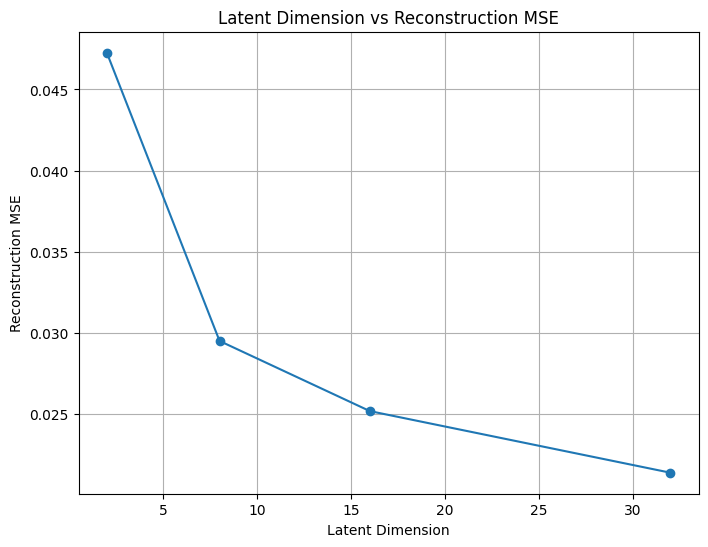

In [ ]:
# ============================================================
# PART 46: LATENT DIMENSION VS MSE
# ============================================================

plt.figure(figsize=(8, 6))

plt.plot(
    latent_dimension_df[
        "Latent Dimension"
    ],

    latent_dimension_df["MSE"],

    marker="o"
)

plt.xlabel(
    "Latent Dimension"
)

plt.ylabel(
    "Reconstruction MSE"
)

plt.title(
    "Latent Dimension vs Reconstruction MSE"
)

plt.grid(True)
plt.show()

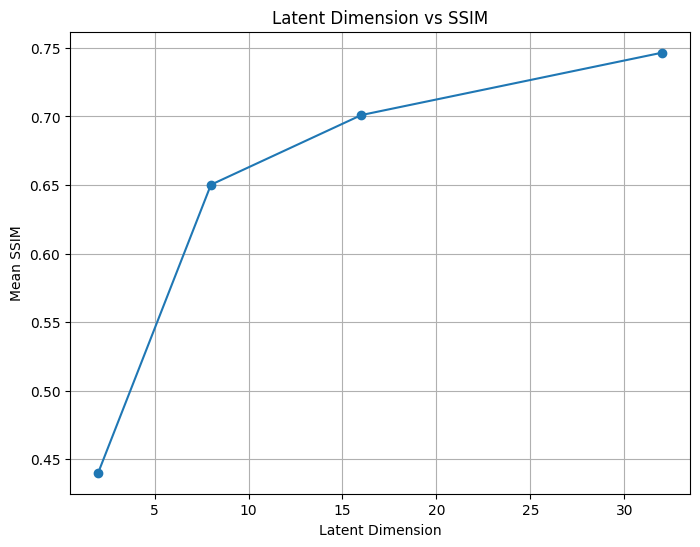

In [ ]:
# ============================================================
# PART 47: LATENT DIMENSION VS SSIM
# ============================================================

plt.figure(figsize=(8, 6))

plt.plot(
    latent_dimension_df[
        "Latent Dimension"
    ],

    latent_dimension_df["SSIM"],

    marker="o"
)

plt.xlabel(
    "Latent Dimension"
)

plt.ylabel(
    "Mean SSIM"
)

plt.title(
    "Latent Dimension vs SSIM"
)

plt.grid(True)
plt.show()

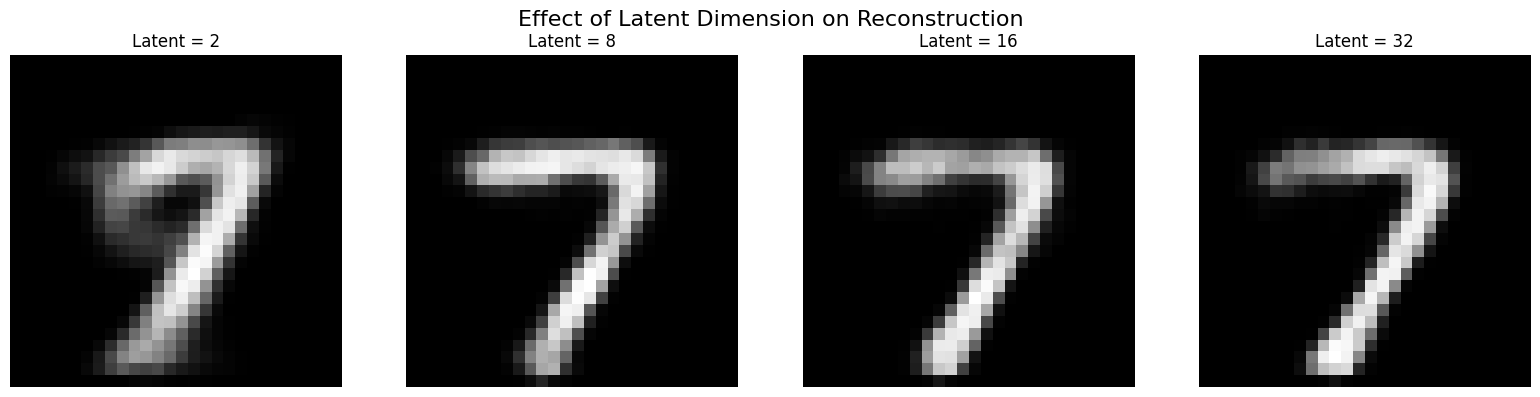

In [ ]:
# ============================================================
# PART 48: LATENT DIMENSION RECONSTRUCTION COMPARISON
# ============================================================

sample_index = 0

plt.figure(figsize=(16, 4))

for position, latent_dim in enumerate(
    latent_dimensions
):

    reconstructed = (
        latent_models[
            latent_dim
        ]["reconstructed"]
    )

    plt.subplot(
        1,
        4,
        position + 1
    )

    plt.imshow(
        reconstructed[
            sample_index
        ].squeeze(),

        cmap="gray"
    )

    plt.title(
        f"Latent = {latent_dim}"
    )

    plt.axis("off")

plt.suptitle(
    "Effect of Latent Dimension on Reconstruction",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# PART 49: CONSOLIDATED RESULTS
# ============================================================

print("=" * 80)
print("EXPERIMENT 7 - CONSOLIDATED RESULTS")
print("=" * 80)

display(final_results)

print("\n")
print("=" * 80)
print("VAE LOSS RESULTS")
print("=" * 80)

display(vae_results)

print("\n")
print("=" * 80)
print("LATENT DIMENSION STUDY")
print("=" * 80)

display(latent_dimension_df)

print("\n")
print("=" * 80)
print("GAUSSIAN NOISE STUDY")
print("=" * 80)

display(noise_results_df)

EXPERIMENT 7 - CONSOLIDATED RESULTS


,Model,MSE,MAE,SSIM,Parameters,Time (seconds)
0,FC Autoencoder,0.024054,0.062523,0.715698,211040,22.597244
1,Convolutional AE,0.002635,0.015328,0.972255,74497,687.111243
2,Denoising CAE,0.004466,0.020804,0.945681,74497,682.341479
3,VAE,0.043744,0.101763,0.488105,485957,357.245038




VAE LOSS RESULTS


,Metric,Value
0,Reconstruction Loss,148.942459
1,KL Loss,5.810935
2,Total Loss,154.753403
3,Test MSE,0.043744
4,Test MAE,0.101763
5,Mean SSIM,0.488105




LATENT DIMENSION STUDY


,Latent Dimension,MSE,SSIM,Parameters,Time (seconds)
0,2,0.047269,0.440026,210130,22.527483
1,8,0.029481,0.650201,210520,23.138099
2,16,0.025153,0.701025,211040,22.529832
3,32,0.021350,0.746539,212080,20.021150




GAUSSIAN NOISE STUDY


,Gaussian Sigma,MSE,MAE,SSIM
0,0.1,0.003476,0.017305,0.961541
1,0.2,0.004490,0.020850,0.945626
2,0.3,0.006890,0.029002,0.863830


In [ ]:
# ============================================================
# PART 50: SAVE RESULTS
# ============================================================

final_results.to_csv(
    "final_model_results.csv",
    index=False
)

vae_results.to_csv(
    "vae_results.csv",
    index=False
)

noise_results_df.to_csv(
    "noise_results.csv",
    index=False
)

latent_dimension_df.to_csv(
    "latent_dimension_results.csv",
    index=False
)

comparison_basic.to_csv(
    "basic_ae_comparison.csv",
    index=False
)

print("All result tables saved successfully.")

All result tables saved successfully.


In [ ]:
# ============================================================
# PART 51: AUTOMATIC OBSERVATIONS
# ============================================================

print("\n" + "=" * 70)
print("OBSERVATIONS")
print("=" * 70)

# ------------------------------------------------------------
# 1. FC-AE vs CAE
# ------------------------------------------------------------

if cae_ssim > fc_ssim:
    print(
        "1. CAE achieved a higher SSIM than FC-AE, "
        "indicating better structural similarity in this execution."
    )
else:
    print(
        "1. FC-AE achieved a higher SSIM than CAE "
        "in this execution."
    )


# ------------------------------------------------------------
# 2. Gaussian Noise
# ------------------------------------------------------------

if (
    noise_results_df["MSE"].iloc[-1]
    >
    noise_results_df["MSE"].iloc[0]
):

    print(
        "2. Reconstruction MSE increased as Gaussian "
        "noise level increased."
    )

else:

    print(
        "2. MSE did not monotonically increase "
        "across the tested noise levels."
    )


if (
    noise_results_df["SSIM"].iloc[-1]
    <
    noise_results_df["SSIM"].iloc[0]
):

    print(
        "3. SSIM decreased as Gaussian noise level increased."
    )

else:

    print(
        "3. SSIM did not monotonically decrease "
        "across the tested noise levels."
    )


# ------------------------------------------------------------
# 3. Latent dimension
# ------------------------------------------------------------

lowest_mse_row = latent_dimension_df.loc[
    latent_dimension_df["MSE"].idxmin()
]

highest_ssim_row = latent_dimension_df.loc[
    latent_dimension_df["SSIM"].idxmax()
]

print(
    f"4. Lowest MSE in the latent-dimension study: "
    f"latent dimension "
    f"{int(lowest_mse_row['Latent Dimension'])}."
)

print(
    f"5. Highest SSIM in the latent-dimension study: "
    f"latent dimension "
    f"{int(highest_ssim_row['Latent Dimension'])}."
)


# ------------------------------------------------------------
# 4. VAE
# ------------------------------------------------------------

print(
    "6. The VAE uses a probabilistic 2-D latent representation "
    "through its learned mean and log-variance."
)

print(
    "7. Random samples were generated by sampling latent "
    "vectors from a standard normal distribution."
)

print(
    "8. Latent interpolation was performed using linear "
    "interpolation between two latent vectors."
)

print(
    "9. High reconstruction-error images were identified "
    "using per-image reconstruction MSE."
)


OBSERVATIONS
1. CAE achieved a higher SSIM than FC-AE, indicating better structural similarity in this execution.
2. Reconstruction MSE increased as Gaussian noise level increased.
3. SSIM decreased as Gaussian noise level increased.
4. Lowest MSE in the latent-dimension study: latent dimension 32.
5. Highest SSIM in the latent-dimension study: latent dimension 32.
6. The VAE uses a probabilistic 2-D latent representation through its learned mean and log-variance.
7. Random samples were generated by sampling latent vectors from a standard normal distribution.
8. Latent interpolation was performed using linear interpolation between two latent vectors.
9. High reconstruction-error images were identified using per-image reconstruction MSE.


In [ ]:
# ============================================================
# PART 52: EXPERIMENT CHECKLIST
# ============================================================

checklist = {
    "1. Original vs FC-AE Reconstruction": True,
    "2. FC-AE Training/Validation Loss": True,
    "3. FC-AE vs CAE Reconstruction": True,
    "4. Clean vs Noisy vs Denoised": True,
    "5. Noise Level vs MSE/MAE/SSIM": True,
    "6. VAE Latent Space": True,
    "7. VAE Generated Images": True,
    "8. VAE Latent Interpolation": True,
    "9. VAE Training/Validation Loss": True,
    "10. Reconstruction Error Distribution": True,
    "11. Five Highest-Error Images": True,
    "12. Latent Dimension vs MSE": True,
    "13. Latent Dimension vs SSIM": True
}

for item, status in checklist.items():

    symbol = "✓" if status else "✗"

    print(
        f"{symbol} {item}"
    )

✓ 1. Original vs FC-AE Reconstruction
✓ 2. FC-AE Training/Validation Loss
✓ 3. FC-AE vs CAE Reconstruction
✓ 4. Clean vs Noisy vs Denoised
✓ 5. Noise Level vs MSE/MAE/SSIM
✓ 6. VAE Latent Space
✓ 7. VAE Generated Images
✓ 8. VAE Latent Interpolation
✓ 9. VAE Training/Validation Loss
✓ 10. Reconstruction Error Distribution
✓ 11. Five Highest-Error Images
✓ 12. Latent Dimension vs MSE
✓ 13. Latent Dimension vs SSIM
